In [1]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt

Data is inflation adjusted, SPY and IEF are fair proxies for these indices. <br> Note: that US stock performance is abnormally high compared to every other country in the 20th and 21st century. Might want to biasing estimates downward or look at expanding to a globally diversified portfolio.

In [2]:
#data source: http://www.econ.yale.edu/~shiller/data.htm
stocknbonddata = pd.read_csv(r"C:\Users\David\Desktop\Codes\Personal-Finance-Resources\Datasets\shiller_stock_data.csv", encoding='utf-8', parse_dates=['Date']).iloc[:,[0,9,18]].dropna().set_index('Date')
stocknbonddata.columns = ['Stock','Long Bonds']
stocknbonddata['Stock'] = stocknbonddata['Stock'].str.replace(',', '').astype(float)
MonRtns = stocknbonddata.pct_change().dropna()

#annualize daily returns
YrRtns = MonRtns.resample("A").apply(lambda x: ((x + 1).cumprod()-1).last("D"))
YrRtns['Stock'] = YrRtns['Stock']

C:\Users\David\AppData\Local\Temp\ipykernel_20092\596262625.py:8: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  YrRtns = MonRtns.resample("A").apply(lambda x: ((x + 1).cumprod()-1).last("D"))
C:\Users\David\AppData\Local\Temp\ipykernel_20092\596262625.py:8: FutureWarning: last is deprecated and will be removed in a future version. Please create a mask and filter using `.loc` instead
  YrRtns = MonRtns.resample("A").apply(lambda x: ((x + 1).cumprod()-1).last("D"))


In [3]:
def weird_growth_bktst(weights, initial_wealth = 1, contrib = 6000, goal = 1500000):
    '''
    This function runs backtests over subsets of the Yr Rtns stock and bond returns data using an array of portfolio weights which should be of same length as the number of max_years_in_workforce (the length of backtests)
    if the terminal wealth is greater than the goal_value at the end of the period than terminal wealth. I don't remember why

    This simulation assumes you add invest your money at the start of the year and that contributions are added at the end of the year
    
    '''
    max_years_in_workforce = 40

    #create wealth array of shape, number of backtests, by the length of the backtest
    backtests = np.ones([len(YrRtns.index[:-max_years_in_workforce]),max_years_in_workforce])

    for step in range(len(YrRtns.index[:-max_years_in_workforce])):
        temp = initial_wealth
        wealth_life = []
        for n in range(max_years_in_workforce):
            port = temp * weights[n]
            port = np.multiply(port, np.array((1+YrRtns.iloc[n+step])))
            temp = sum(port)
            temp += contrib
            if temp >= goal:
                temp = goal
            wealth_life.append(temp)
        backtests[step,:] = wealth_life
    df = pd.DataFrame(backtests,index=YrRtns.index[:-max_years_in_workforce])
    print("contrib Annually:", contrib)
    return df

def sum_cond_fail(df, goal = 1.5*10**6, withdraw_rate = .04):
    print("years port reached goal in 40 years:", (df.iloc[:,-1]>=goal).sum())
    print("years port failed to reach goal in 40 years:", (df.iloc[:,-1]<goal).sum())
    print("average of years goal is not met:",df.iloc[:,-1].loc[df.iloc[:,-1]<goal].mean()*withdraw_rate)
    #print("std failure:",df.iloc[:,-1].loc[df.iloc[:,-1]<goal].std())
    print("7th percentile income:", (df.iloc[:,-1].loc[df.iloc[:,-1]<goal].mean()-df.iloc[:,-1].loc[df.iloc[:,-1]<goal].std())*withdraw_rate)


In [12]:
#inputs! 
contributions = 13500   #13500: 6000 roth ira contrib, 5000 roth 401K contrib, 2500 roth 401K matching
starting_wealth = 10000
income_in_retirement = 60000

#calculation
withdraw_rate = .027 #most target date funds only have 30% allocation to stocks in retirement, 
                        #I know I've seen research that the 4% rule is not sustainable with a risk allocation that low in retirement, 
                        # need to find sources for this, also 4% rule was created using US data which has performed abnormally well. Should add sources for this
                        # source for now: https://www.youtube.com/watch?v=1FwgCRIS0Wg&t=680s

goal = income_in_retirement/withdraw_rate 

avg stock weight 0.76
contrib Annually: 13500
years port reached goal in 40 years: 34
years port failed to reach goal in 40 years: 78
average of years goal is not met: 48104.558471805765
7th percentile income: 39286.17390532729


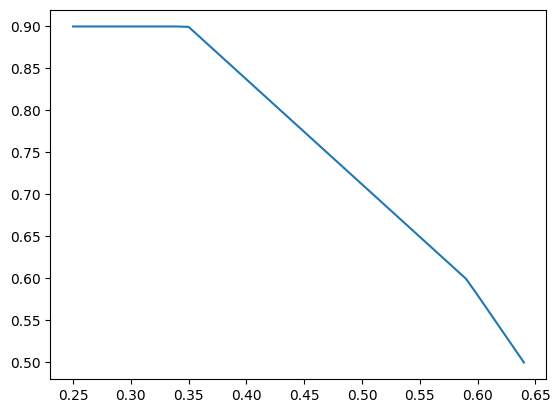

In [34]:
#traditional glide path
def glide_path(x):
    if x<.35:
        return .9
    elif .35<=x<.60:
        return 1.337-1.25*x
    elif .60<=x:
        return 1.78-2.0*x

#years of life/100 to make the math work
x = np.arange(.25,.65,.01)  
plt.plot(x,list(map(glide_path,x)))
print('avg stock weight',np.array(list(map(glide_path,x))).mean().round(2))
#use glide path to set stock weights and 1-stock weight to set bond path
glide_weights = np.concatenate([np.array(list(map(glide_path,x))).reshape(1,-1), 1-np.array(list(map(glide_path,x))).reshape(1,-1)],axis=0).T

bktst = weird_growth_bktst(glide_weights,initial_wealth = starting_wealth,contrib = contributions, goal = goal)
sum_cond_fail(bktst, goal, withdraw_rate)

In [15]:
#compare to static allocation
glide_path = lambda y: .76+y*0
glide_weights = np.concatenate([glide_path(x).reshape(1,-1),np.array([1-glide_path(x)])],axis=0).T

bktst = weird_growth_bktst(glide_weights, initial_wealth = starting_wealth, contrib = contributions, goal = goal)
sum_cond_fail(bktst, goal, withdraw_rate ) 
#76/24

contrib Annually: 13500
years port reached goal in 40 years: 37
years port failed to reach goal in 40 years: 75
average of years goal is not met: 46908.42986367988
7th percentile income: 37928.59537224609


avg stock weight 0.76
contrib Annually: 13500
years port reached goal in 40 years: 32
years port failed to reach goal in 40 years: 80
average of years goal is not met: 47285.97403235564
7th percentile income: 37929.60359231442


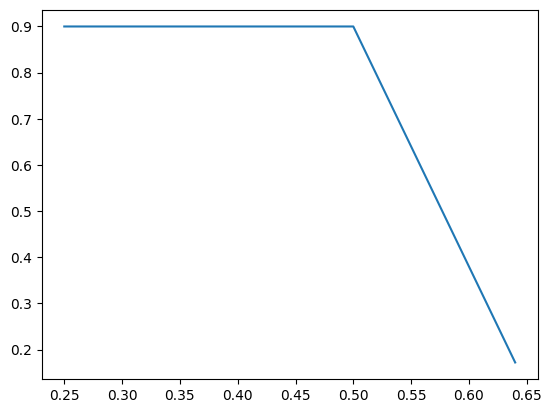

In [36]:
#aggressive glide path

def glide_path(x):
    if x<.50:
        return .9
    elif .50<=x<.65:
        return 3.5-5.2*x

#years of life/100 to make the math work
x = np.arange(.25,.65,.01)  
plt.plot(x,list(map(glide_path,x)))
print('avg stock weight',np.array(list(map(glide_path,x))).mean().round(2))

#use glide path to set stock weights and 1-stock weight to set bond path
glide_weights = np.concatenate([np.array(list(map(glide_path,x))).reshape(1,-1), 1-np.array(list(map(glide_path,x))).reshape(1,-1)],axis=0).T

bktst = weird_growth_bktst(glide_weights,initial_wealth = starting_wealth,contrib = contributions, goal = goal)
sum_cond_fail(bktst, goal, withdraw_rate)